# Лабораторная работа 3
## Вариант 10

In [82]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from itertools import combinations

FLOW - массовый расход газа (кг/с).

PIN - давление на всасывании (МПа).

POUT - давление на нагнетании (МПа).

TIN - температура на всасывании (°C).

TOUT - температура на нагнетании (°C).

RPM - частота вращения ротора (об/мин).

VIB - уровень вибрации (мм/с).

AMB - температура окружающего воздуха (°C).

MW - молекулярная масса газовой смеси (г/моль).

COMP - степень сжатия (отношение POUT / PIN).

POWER - Целевая переменная : Потребляемая мощность электродвигателя компрессора (кВт).

10 POWER COMP TIN

# Задание 1

Загрузите данные исторических режимов работы центробежного компрессора (CSV-файл).

In [83]:
df = pd.read_csv('compressor_dataset.csv')
df.head(7)

,FLOW,PIN,POUT,TIN,TOUT,RPM,VIB,AMB,MW,COMP,POWER
0,87.45,2.37,4.49,30.2,115.8,8575.0,2.26,11.5,17.02,1.893,6320.0
1,145.07,3.08,5.77,33.9,114.4,10342.0,2.45,24.3,15.59,1.870,8759.2
2,123.20,3.75,10.71,17.5,154.9,10673.0,1.42,21.8,17.17,2.859,9331.1
3,109.87,3.46,6.49,28.7,118.3,9470.0,2.33,-11.5,18.23,1.874,7230.3
4,65.60,3.61,6.89,27.2,109.3,7732.0,0.86,-11.8,17.93,1.908,6197.6
5,65.60,3.32,8.76,35.0,147.1,8582.0,2.10,-5.3,17.84,2.639,7123.6
6,55.81,3.38,7.36,37.2,133.1,7443.0,1.41,-0.1,17.28,2.175,6144.2


# Задание 2. 
Создайте датафрейм, выделите целевую переменную (POWER) и выведите первые семь строк.\
Разделите выборку на обучающую и тестовую части (train_test_split). \
Используйте одно и то же разделение для всех моделей регрессии, \
меняя при необходимости только количество участвующих в обучении предикторов.

In [84]:
X_train, X_test, y_train, y_test = train_test_split(df[["TIN", "COMP"] ], 
                                                    df["POWER"],
                                                    test_size=0.2,
                                                    random_state=52)
X_train.head()

,TIN,COMP
836,38.0,2.990
670,17.1,2.467
33,13.0,2.958
991,16.3,2.700
993,11.5,2.095


# Задание 3

## Задание 3.1. 
Постройте точечную диаграмму (scatter plot) с переменными согласно вашему варианту (см. Таблицу 1). \
Какие выводы о характере зависимости можно сделать на основе этого графика?

Text(0.5, 1.0, 'TIN vs POWER')

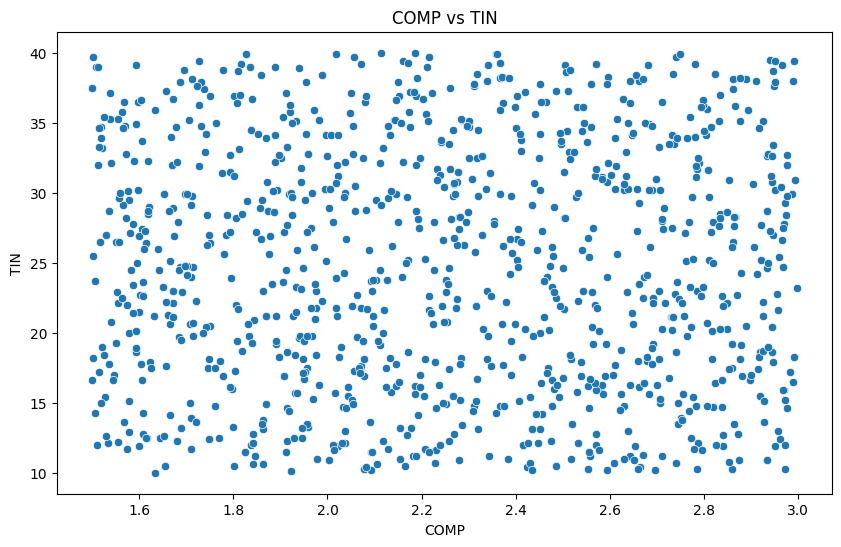

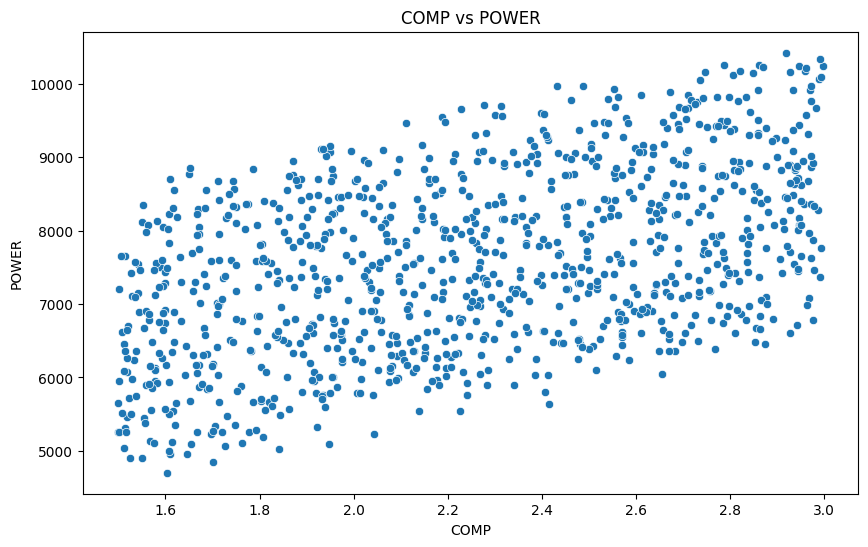

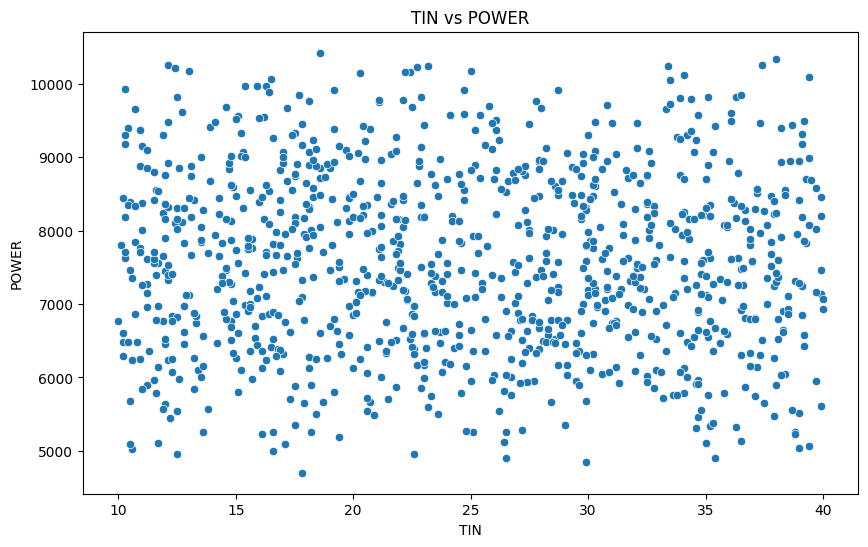

In [85]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df["COMP"], y=df["TIN"])
plt.title("COMP vs TIN")
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df["COMP"], y=df["POWER"])
plt.title("COMP vs POWER")
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df["TIN"], y=df["POWER"])
plt.title("TIN vs POWER")

### Вывод: с температурой на входе нет никаких выводов, при повышении компрессии увеличивается мощность

## Задание 3.2

Постройте модель линейной регрессии (LinearRegression) для предикторов согласно варианту.\
 Оцените качество регрессии по метрикам RMSE и R².


In [86]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_train_pred_lr = lr_model.predict(X_train)
y_test_pred_lr = lr_model.predict(X_test)

rmse_train_lr = np.sqrt(mean_squared_error(y_train, y_train_pred_lr))
rmse_test_lr = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))
r2_train_lr = r2_score(y_train, y_train_pred_lr)
r2_test_lr = r2_score(y_test, y_test_pred_lr)

print("Линейная регрессия (COMP + TIN):" ,
f"Коэффициенты: COMP = {lr_model.coef_[0]:.4f}, TIN = {lr_model.coef_[1]:.4f}",
f"Свободный член: {lr_model.intercept_:.4f}",
"Обучающая выборка:",
f"RMSE = {rmse_train_lr:8.2f}",
f"R^2 = {r2_train_lr:8.4f}" ,
"Тестовая выборка:" ,
f"RMSE = {rmse_test_lr:8.2f}",
f"R^2 = {r2_test_lr:8.4f}", sep="\n"
)


Линейная регрессия (COMP + TIN):
Коэффициенты: COMP = -3.1474, TIN = 1331.5047
Свободный член: 4663.4171
Обучающая выборка:
RMSE =  1046.85
R^2 =   0.2326
Тестовая выборка:
RMSE =  1103.59
R^2 =   0.2534


### Выводы: отклонения большие, r^2 не очень близок к единице - модель линейной регрессии неудачная

## Задание 3.3

Постройте нелинейную модель для тех же предикторов. \
Для чётного варианта используйте модель полинома второй степени ($y = ax^2 + bx + c$, через PolynomialFeatures), \
для нечётного — экспоненциальную модель ($y = a \cdot e^{bx}$), \
которую можно линеаризовать к виду $\ln(y) = c + d \cdot x$, \
предварительно прологарифмировав целевую переменную (np.log(y)). \
Оцените качество по RMSE и R².

In [87]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Обучение модели
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Прогнозы
y_train_pred_poly = poly_model.predict(X_train_poly)
y_test_pred_poly = poly_model.predict(X_test_poly)

# Метрики
rmse_train_poly = np.sqrt(mean_squared_error(y_train, y_train_pred_poly))
rmse_test_poly = np.sqrt(mean_squared_error(y_test, y_test_pred_poly))
r2_train_poly = r2_score(y_train, y_train_pred_poly)
r2_test_poly = r2_score(y_test, y_test_pred_poly)

print("Полиномиальная регрессия (степень 2, COMP + TIN):",
f"Количество признаков после PolynomialFeatures: {X_train_poly.shape[1]}",
"(COMP, TIN, COMP², COMP×TIN, TIN²)",
"Обучающая выборка:",
f"RMSE = {rmse_train_poly:8.2f}",
f"R² = {r2_train_poly:8.4f}",
"Тестовая выборка:",
f"RMSE = {rmse_test_poly:8.2f}",
f"R² = {r2_test_poly:8.4f}", sep="\n")

Полиномиальная регрессия (степень 2, COMP + TIN):
Количество признаков после PolynomialFeatures: 5
(COMP, TIN, COMP², COMP×TIN, TIN²)
Обучающая выборка:
RMSE =  1046.70
R² =   0.2328
Тестовая выборка:
RMSE =  1102.96
R² =   0.2542


### Вывод: полиномилальная регрессия второго уровня не подходит

# Задание 4

## Задание 4.1. 
Постройте матрицу корреляции (sns.heatmap) всех переменных в датасете.\
 Какие из параметров сильнее всего влияют на целевую переменную POWER?\
  Модели последовательно постройте от каждого значимого параметра и их возможных комбинаций.\
   Значимость определяется значением коэффициента корреляции (больше 0.5 по модулю). \
   Оцените качество полученных моделей по RMSE и R².

Text(0.5, 1.0, 'Корреляционная матрица')

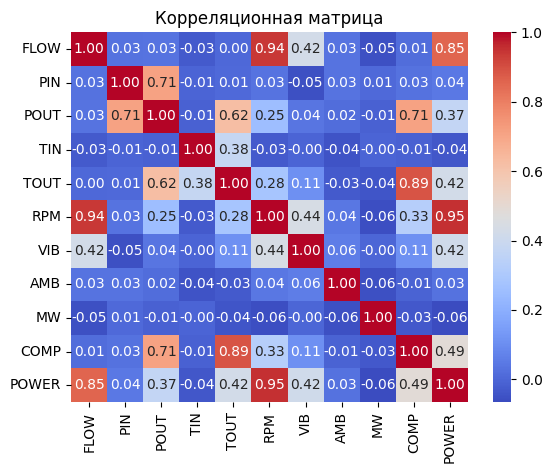

In [88]:
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Корреляционная матрица")

In [89]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=["POWER"]),
                                                    df["POWER"],
                                                    test_size=0.2,
                                                    random_state=52)
X_train.head()

power_corr = corr_matrix["POWER"].abs().sort_values(ascending=False)
print("Корреляция признаков с целевой переменной POWER:")
for feat, corr_val in power_corr.items():
    if feat != "POWER":
        marker = "+" if corr_val > 0.5 else "-"
        print(f" {marker} {feat:6s}: {corr_val:+.4f}")

significant_features = [f for f in power_corr.index if f != "POWER" and power_corr[f] > 0.5]

model_results = dict()

for r in range(1, len(significant_features) + 1):
    for combo in combinations(significant_features, r):
        X_train_combo = X_train[list(combo)]
        X_test_combo = X_test[list(combo)]

        features = list(combo)

        lr_model.fit(X_train_combo, y_train)
        y_test_pred = lr_model.predict(X_test_combo)
        rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
        r2 = r2_score(y_test, y_test_pred)
        
        model_results[combo] = {
            'RMSE_test': rmse,
            'R2_test': r2,
            'features': features
        }
best_model = min(model_results, key=lambda k: model_results[k]['RMSE_test'])
best_rmse = model_results[best_model]['RMSE_test']
best_r2 = model_results[best_model]['R2_test']
best_features = model_results[best_model]['features']
print(f"\n Лучшая модель: {best_features}",
f"RMSE = {best_rmse:.2f}",
f"R² = {best_r2:.4f}", sep="\n")

Корреляция признаков с целевой переменной POWER:
 + RPM   : +0.9537
 + FLOW  : +0.8545
 - COMP  : +0.4869
 - TOUT  : +0.4234
 - VIB   : +0.4173
 - POUT  : +0.3705
 - MW    : +0.0649
 - PIN   : +0.0437
 - TIN   : +0.0360
 - AMB   : +0.0289

 Лучшая модель: ['RPM', 'FLOW']
RMSE = 318.17
R² = 0.9379


### Вывод: на целевую переменную больше всего влияют частота вращения ротора и массовый расход газа

## Задание 4.2. 
Возьмите все доступные признаки и поместите их в переменную X. \
Целевую переменную POWER поместите в переменную y. \
Постройте модель множественной линейной регрессии для всех предикторов.\
 Оцените качество регрессии по RMSE и R².

In [90]:
mlr_model = LinearRegression()
mlr_model.fit(X_train, y_train)

y_train_pred_mlr = mlr_model.predict(X_train)
y_test_pred_mlr = mlr_model.predict(X_test)

rmse_train_mlr = np.sqrt(mean_squared_error(y_train, y_train_pred_mlr))
rmse_test_mlr = np.sqrt(mean_squared_error(y_test, y_test_pred_mlr))
r2_train_mlr = r2_score(y_train, y_train_pred_mlr)
r2_test_mlr = r2_score(y_test, y_test_pred_mlr)
print("Множественная линейная регрессия (все признаки):",
f"Коэффициенты: {dict(zip(X_train.columns, mlr_model.coef_))}",
f"Свободный член: {mlr_model.intercept_:.4f}",
"Обучающая выборка:",
f"RMSE = {rmse_train_mlr:8.2f}",
f"R² = {r2_train_mlr:8.4f}",
"Тестовая выборка:",
f"RMSE = {rmse_test_mlr:8.2f}",
f"R² = {r2_test_mlr:8.4f}", sep="\n")

coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': mlr_model.coef_,
    'abs_coef': np.abs(mlr_model.coef_)
}).sort_values('abs_coef', ascending=False)

print("5 важнейших признаков по влиянию на POWER (по модулю коэффициента):")
for i, row in coef_df.head(5).iterrows():
    print(f"{row['feature']:6s}: {row['coefficient']:>+9.3f}")

Множественная линейная регрессия (все признаки):
Коэффициенты: {'FLOW': np.float64(31.366079193494325), 'PIN': np.float64(-8.974289589246792), 'POUT': np.float64(13.891268773636229), 'TIN': np.float64(-2.1528235096084654), 'TOUT': np.float64(1.4882804594231018), 'RPM': np.float64(0.1025557813166822), 'VIB': np.float64(20.254891169053806), 'AMB': np.float64(-0.050683475896786546), 'MW': np.float64(-6.926902724385227), 'COMP': np.float64(1115.8513470961564)}
Свободный член: 887.7014
Обучающая выборка:
RMSE =   256.93
R² =   0.9538
Тестовая выборка:
RMSE =   247.43
R² =   0.9625
5 важнейших признаков по влиянию на POWER (по модулю коэффициента):
COMP  : +1115.851
FLOW  :   +31.366
VIB   :   +20.255
POUT  :   +13.891
PIN   :    -8.974


## Задание 4.3. 
В сводной таблице сравните качество моделей регрессии (из заданий 3.2, 3.3, 4.1, 4.2) на тестовой выборке.\
 Как повлияло включение или исключение тех или иных предикторов на точность обученных моделей?\
  Какие признаки оказались более значимыми?\
   Как повлияло применение нелинейных моделей (задание 3.3) на точность по сравнению с линейной?\
    Какая модель получилась наиболее точной?

Сводная таблица результатов моделей:
            Модель  Кол-во признаков RMSE (тест) R² (тест)            Признаки
 LR (все признаки)                10      247.43    0.9625  FLOW, PIN, POUT...
   ('RPM', 'FLOW')                 2      318.17    0.9379           RPM, FLOW
          ('RPM',)                 1      359.90    0.9206                 RPM
         ('FLOW',)                 1      663.34    0.7302                FLOW
Poly2 (COMP + TIN)                 5     1102.96    0.2542 COMP, TIN, COMP²...
   LR (COMP + TIN)                 2     1103.59    0.2534           COMP, TIN


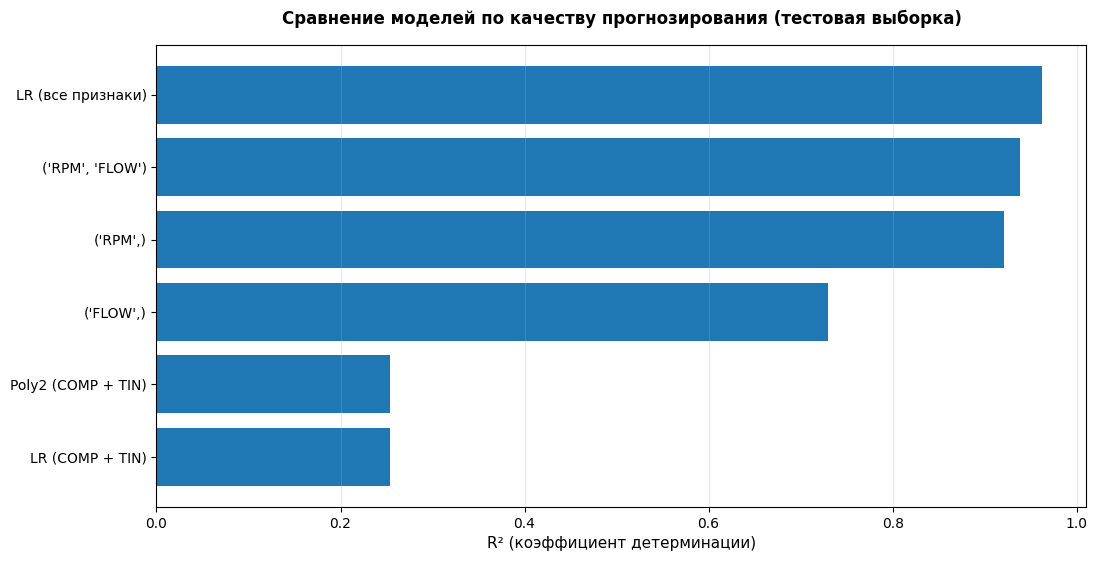

In [91]:
model_results['LR (COMP + TIN)'] = {
    'RMSE_test': rmse_test_lr,
    'R2_test': r2_test_lr,
    'features': ['COMP', 'TIN']
}
model_results['Poly2 (COMP + TIN)'] = {
    'RMSE_test': rmse_test_poly,
    'R2_test': r2_test_poly,
    'features': ['COMP', 'TIN', 'COMP²', 'COMP×TIN', 'TIN²']
}
model_results['LR (все признаки)'] = {
    'RMSE_test': rmse_test_mlr,
    'R2_test': r2_test_mlr,
    'features': list(X_train.columns)
}

# Создаём сводную таблицу
summary_data = []
for name, res in model_results.items():
    summary_data.append({
        'Модель': str(name),
        'Кол-во признаков': len(res['features']),
        'RMSE (тест)': f"{res['RMSE_test']:.2f}",
        'R² (тест)': f"{res['R2_test']:.4f}",
        'Признаки': ', '.join(res['features'][:3]) + ('...' if len(res['features']) > 3 else '')
    })

summary_df = pd.DataFrame(summary_data).sort_values('R² (тест)', ascending=False)

print("Сводная таблица результатов моделей:")
print(summary_df.to_string(index=False))

plt.figure(figsize=(12, 6))
summary_df_plot = summary_df.copy() 
summary_df_plot['R² (тест)'] = summary_df_plot['R² (тест)'].astype(float)

bars = plt.barh(summary_df_plot['Модель'], summary_df_plot['R² (тест)'])
plt.xlabel('R² (коэффициент детерминации)', fontsize=11)
plt.title('Сравнение моделей по качеству прогнозирования (тестовая выборка)', 
          fontsize=12, fontweight='bold', pad=15)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)


# Задание 5
Оцените качество моделей через R². \
Какую долю изменчивости целевой переменной объясняет модель, учитывающая все признаки? \
Какая модель имеет наибольший R² и почему?

### Самый высокий коэффициент r^2 имеет модель, учитывающая все приззнаки, но на близком уровне модели, учитывающие RPM и FLOW. 
### Модель обьясняет 96,25% значений, а остальные 3,75% можно обьяснить шумом в данных и возможными неучтенными данными.
